In [1]:
import os
import csv
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torchvision.io import read_image
from torchvision import models
from torchvision.transforms import v2 as transforms
from torch.utils.data import Dataset, SubsetRandomSampler
from safetensors.torch import save_model, load_model
import torchvision.transforms.functional as F

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [3]:
class SquarePad:
    def __call__(self, image):
        c, h, w = image.size()
        max_wh = np.max([w, h])
        hp = (max_wh - w) // 2 + max_wh // 10
        vp = (max_wh - h) // 2 + max_wh // 10
        padding = (hp, vp, hp, vp)
        return F.pad(image, padding, 1, 'constant')

def image_transform(test=False):
    # normalize = transforms.Normalize(
    #     mean=[0.4914, 0.4822, 0.4465],
    #     std=[0.2023, 0.1994, 0.2010],
    # )
    mid_transforms = [
    ] if test else [
        # transforms.RandomHorizontalFlip(),
        # transforms.RandomVerticalFlip(),
        #transforms.RandomAffine(degrees=10, translate=(0.1,0.1), scale=(0.9,1.1)),
        #transforms.ColorJitter(),
        # transforms.GaussianBlur(5),
    ]
    return transforms.Compose([
        transforms.ConvertImageDtype(torch.float),
        transforms.RGB(),
        SquarePad(),
    ] + mid_transforms + [
        transforms.Resize((224,224)),
        # normalize,
        transforms.Lambda(lambda x: torch.clamp(x, 0, 1))
    ])


def load_image(path):
    transform = image_transform(test=True)
    image = read_image(path)
    image = transform(image)
    return image

In [ ]:
# Load the dataset
sim_df = pd.read_csv('../data/similar.csv', header=None, index_col=None)
sim_df = [group.split(' ') for _, row in sim_df.items() for group in row]
sim_df

[['1001179.jpg', '1014250.jpg', '1000349.jpg'],
 ['1000015.jpg', '1000016.jpg'],
 ['1000053.jpg', '1000054.jpg'],
 ['1000108.jpg', '1000109.jpg'],
 ['1000116.jpg', '1000117.jpg'],
 ['1000161.jpg', '1000162.jpg'],
 ['1000374.jpg', '1000383.jpg'],
 ['1000400.jpg', '1000401.jpg'],
 ['1000532.jpg', '1000533.jpg', '1000534.jpg'],
 ['1000571.jpg', '1000572.jpg'],
 ['1000659.jpg', '1000660.jpg'],
 ['1000672.jpg', '1000673.jpg'],
 ['101863.jpg', '101864.jpg', '101869.jpg'],
 ['106155.jpg', '106156.jpg'],
 ['106268.jpg', '106269.jpg', '106270.jpg'],
 ['106741.jpg', '106742.jpg'],
 ['109785.jpg', '109786.jpg'],
 ['1001174.jpg', '1001175.jpg'],
 ['1001181.jpg', '1001182.jpg'],
 ['1001217.jpg', '1001220.jpg'],
 ['1001683.jpg', '1001689.jpg'],
 ['1001723.jpg', '1001724.jpg'],
 ['1001780.jpg', '1001790.jpg'],
 ['1001831.jpg', '1001832.jpg'],
 ['1002174.jpg', '1002175.jpg'],
 ['1002246.jpg', '1002247.jpg'],
 ['1002316.jpg', '1002317.jpg'],
 ['1002420.jpg', '1002421.jpg'],
 ['1002430.jpg', '1002431.jp

10it [00:00, 85.51it/s]


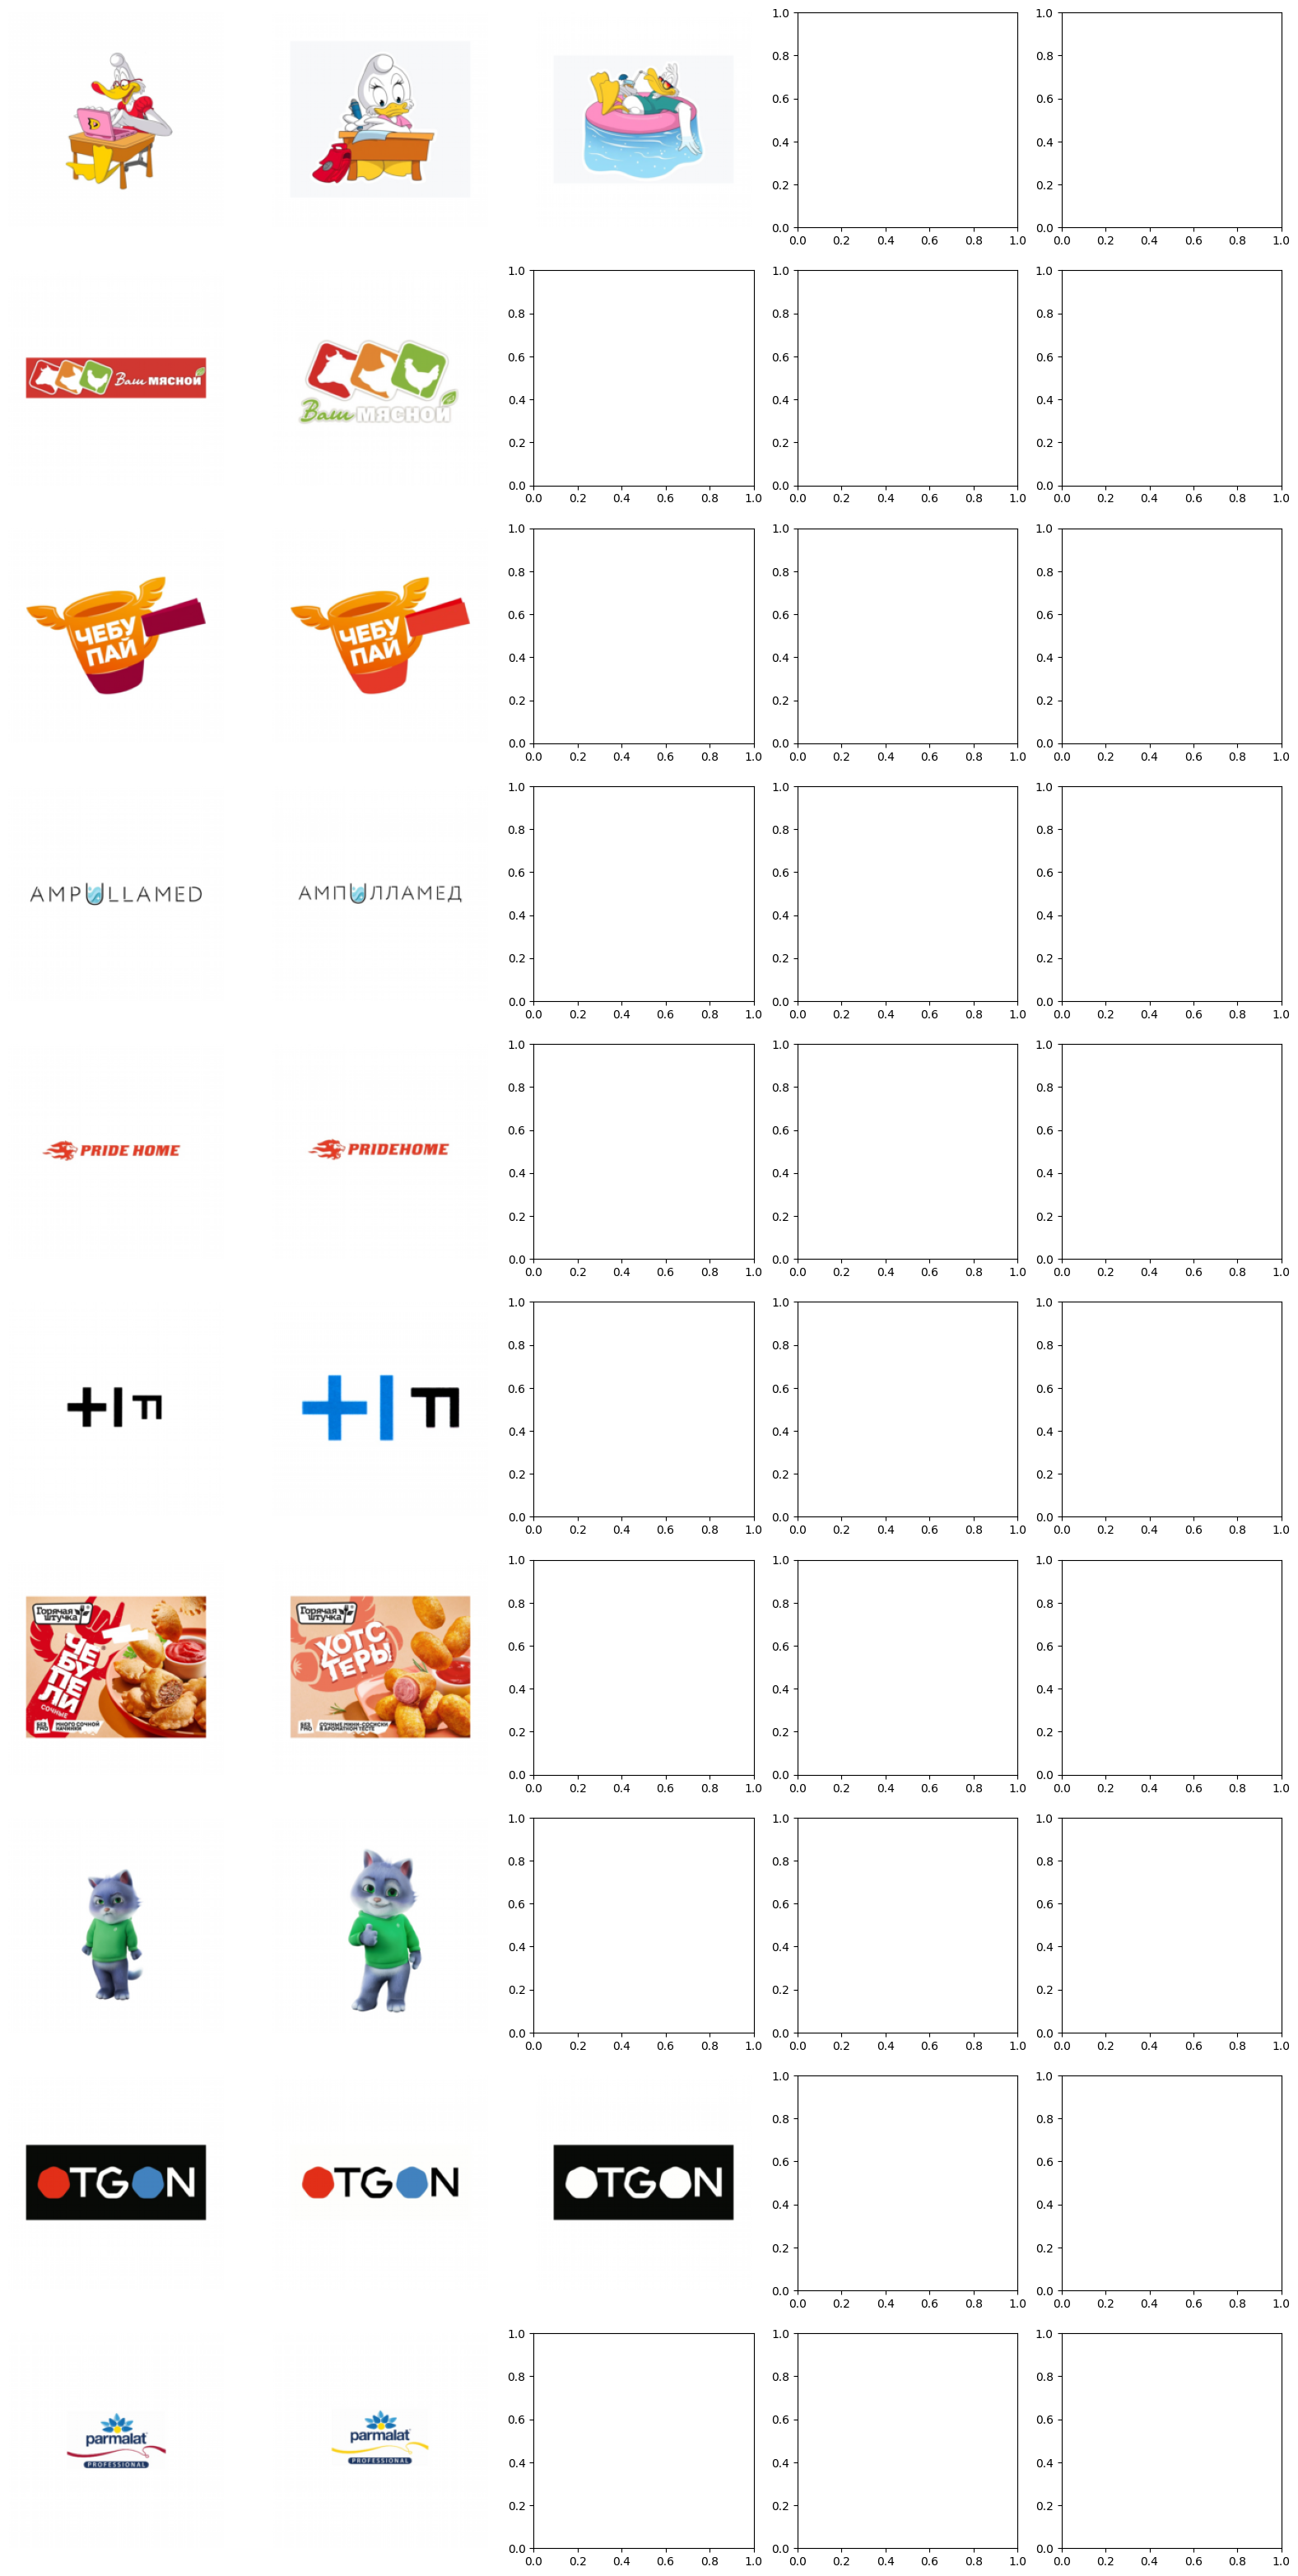

In [ ]:
# View examples from the dataset
w, h = 5, 10
_, axs = plt.subplots(h, w, figsize=(w * 4, h * 4))

similarity_fn = nn.CosineSimilarity()
for ax_row, paths in tqdm(zip(axs, sim_df)):
    for i_col, (ax, path) in enumerate(zip(ax_row, paths)):
        img_path = os.path.join('../data/logos/', path)
        img = load_image(img_path)
        ax.set_axis_off()
        ax.imshow(img.transpose(0,1).transpose(1,2))

plt.show()

10it [00:00, 94.88it/s]


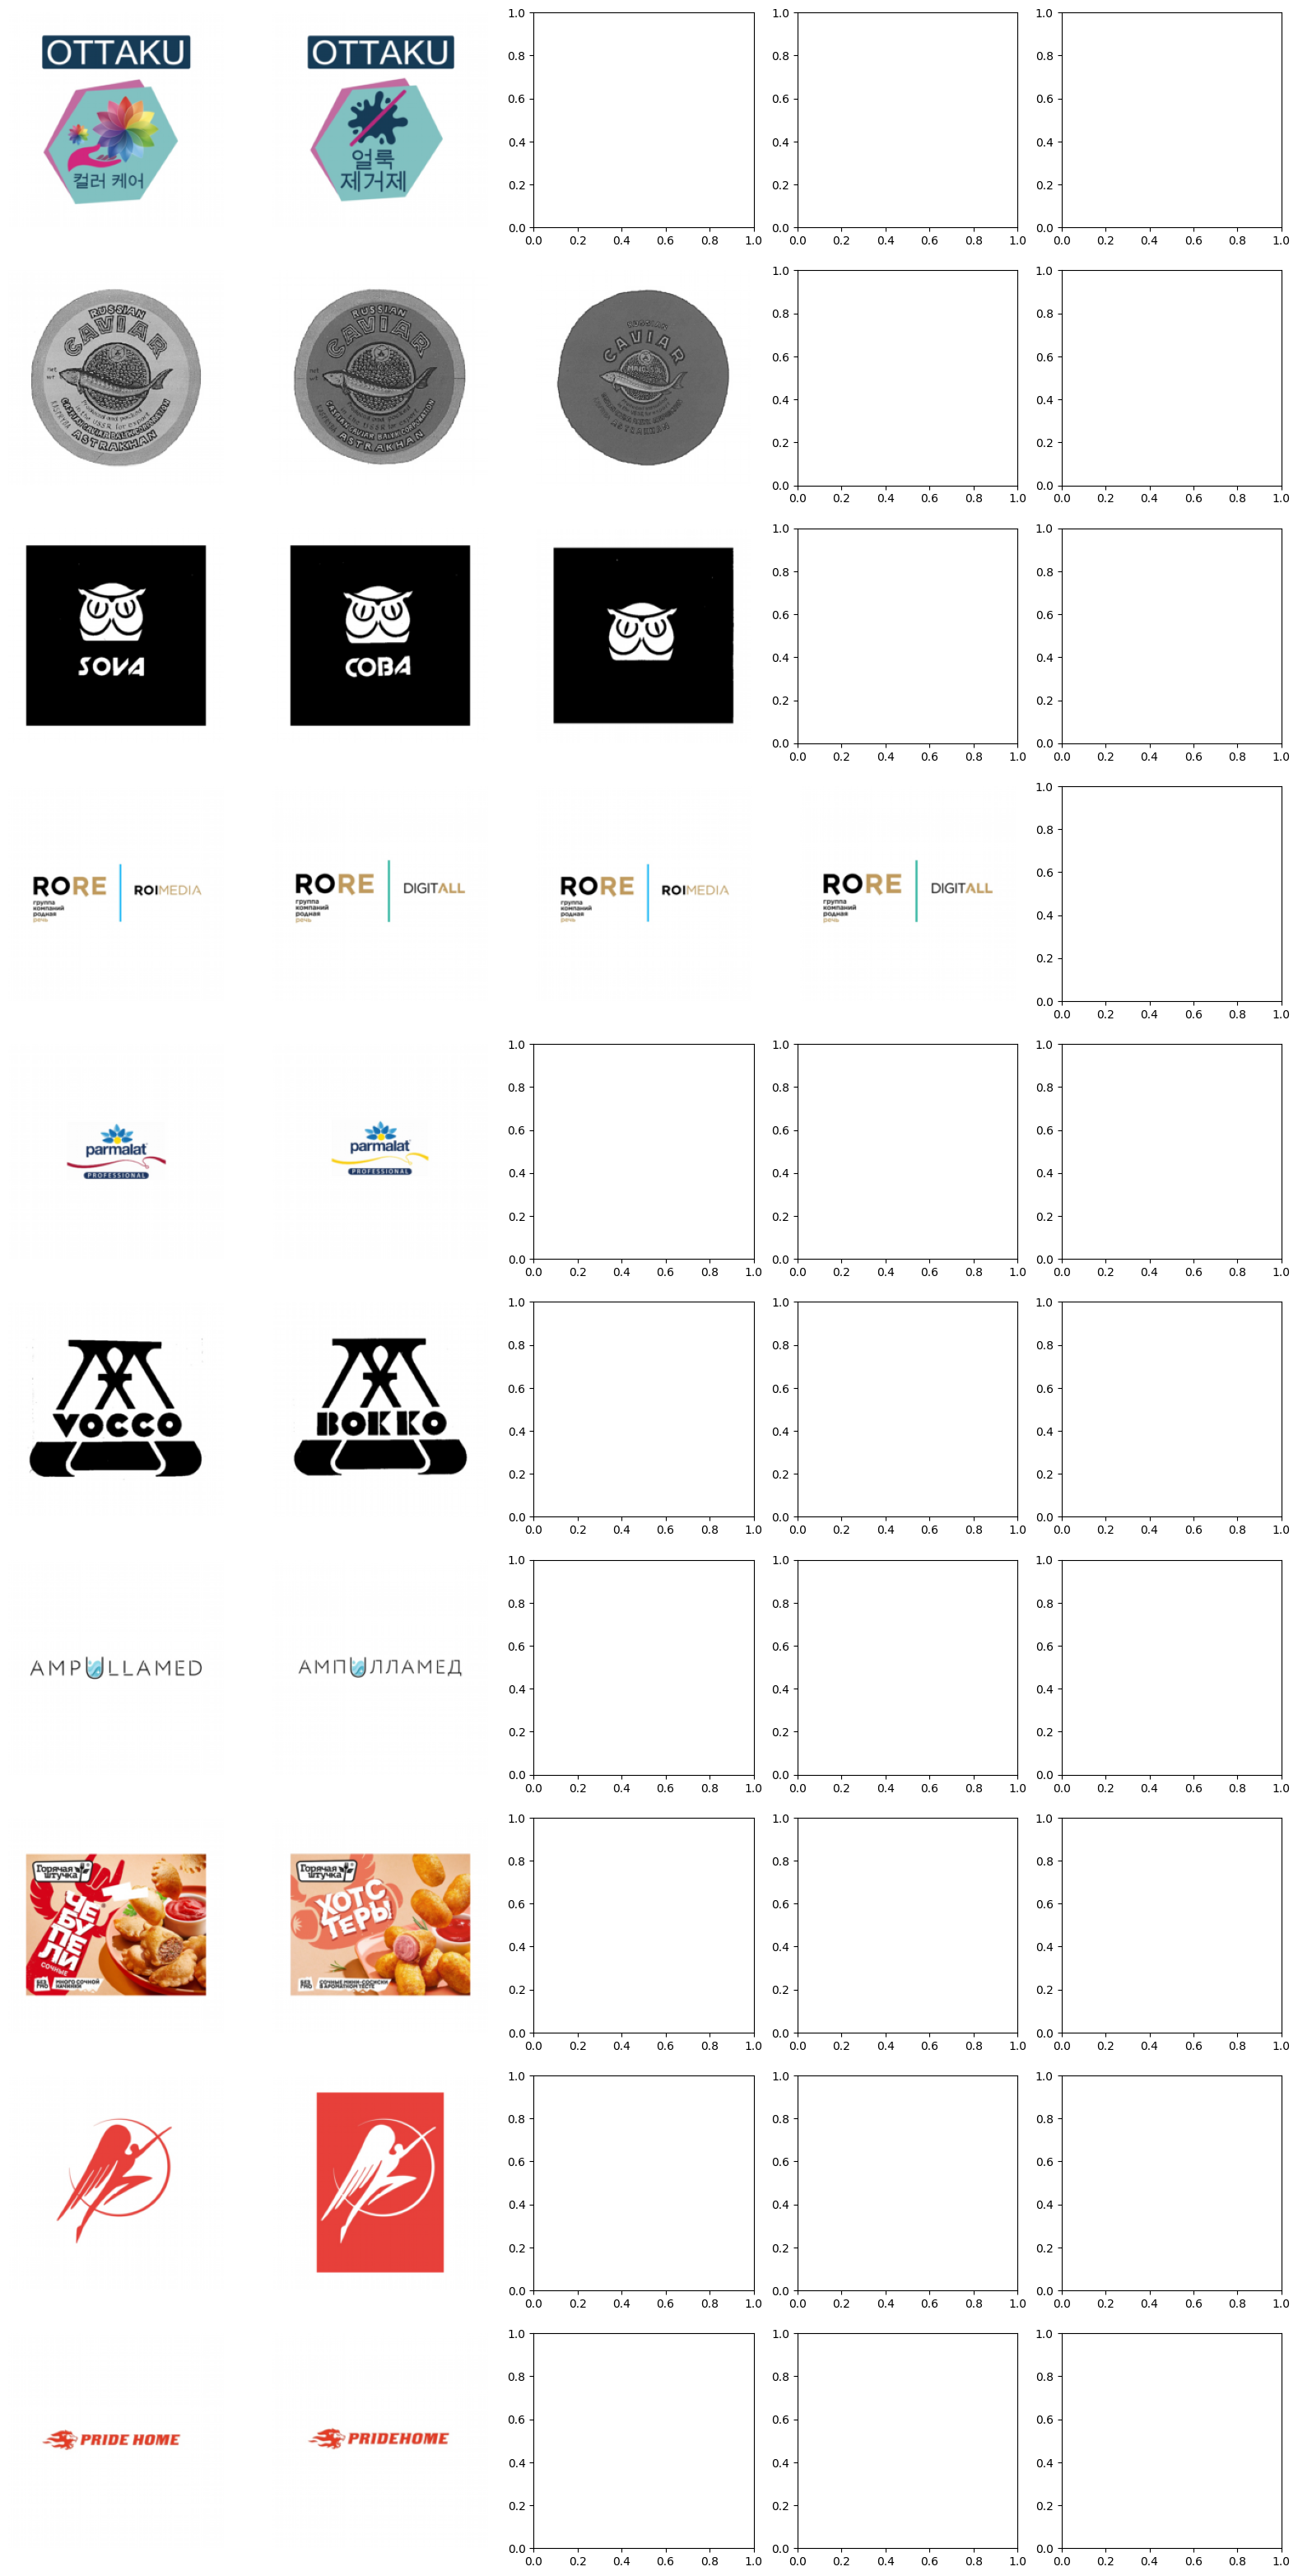

In [ ]:
# View examples from the dataset
w, h = 5, 10
_, axs = plt.subplots(h, w, figsize=(w * 4, h * 4))

# Random order
sim_df_clone = sim_df.copy()
np.random.shuffle(sim_df_clone)

similarity_fn = nn.CosineSimilarity()
for ax_row, paths in tqdm(zip(axs, sim_df_clone)):
    for i_col, (ax, path) in enumerate(zip(ax_row, paths)):
        img_path = os.path.join('../data/logos/', path)
        img = load_image(img_path)
        ax.set_axis_off()
        ax.imshow(img.transpose(0,1).transpose(1,2))

plt.show()

In [15]:
# Setup the similarity model
def compute_similarity(image_path, embeddings, model):
    image = load_image(image_path)
    encoded = model.to(device)(image.unsqueeze(0).to(device)).detach()

    similarity_fn = nn.CosineSimilarity()
    def similarity(other_enc):
        return similarity_fn(encoded, other_enc)
    similarity_vec = torch.vmap(similarity)
    return similarity_vec(embeddings)


def load_similarity_model():
    model = models.vgg16(weights=models.VGG16_Weights.DEFAULT).to(device)
    model.eval()
    return model


model = load_similarity_model()


def calculate_similarity(image_path, embeddings_path=None):
    if embeddings_path is None:
        embeddings_path = '../models/logos_embedding.pt'
    embeddings_path_root, _ = os.path.splitext(embeddings_path)
    embeddings_paths_path = embeddings_path_root + '.csv'
    if not os.path.exists(embeddings_path):
        print(f'Embeddings at `{embeddings_path}` not found')
        return
    if not os.path.exists(embeddings_paths_path):
        print(f'Embeddings paths csv file at `{embeddings_paths_path}` not found')
        return

    embeddings = torch.load(embeddings_path)
    embeddings_paths = pd.read_csv(embeddings_paths_path, header=None, index_col=None)[0].tolist()

    # Compute
    similarities = compute_similarity(image_path, embeddings, model).cpu().numpy().flatten()
    return similarities, embeddings_paths

In [30]:
# Test the dataset for top-10 hits
total_checks = 0
misses = []

for paths in tqdm(sim_df):
    for path_i, path_j in zip(paths, paths[1:]):
        path_i_real = os.path.join('../data/logos/', path_i)
        path_j_real = os.path.join('../data/logos/', path_j)

        # Test i->j
        similarities, embeddings_paths = calculate_similarity(path_i_real)
        top_images = np.argsort(similarities)[::-1]
        top_n = 10
        top_paths = [embeddings_paths[i] for i in top_images[:top_n]]
        total_checks += 1
        if os.path.join('data/logos/', path_j) not in top_paths:
            misses.append((path_i_real, path_j_real))

        # Test j->i
        similarities, embeddings_paths = calculate_similarity(path_j_real)
        top_images = np.argsort(similarities)[::-1]
        top_n = 10
        top_paths = [embeddings_paths[i] for i in top_images[:top_n]]
        total_checks += 1
        if os.path.join('data/logos/', path_i) not in top_paths:
            misses.append((path_j_real, path_i_real))

100%|██████████| 32/32 [00:23<00:00,  1.38it/s]


In [31]:
print(f'Samples: {total_checks}, Misses: {len(misses)}')
accuracy = 1.0 - len(misses) / total_checks
print(f'Accuracy: {accuracy * 100.0:.2f}%')

Samples: 88, Misses: 32
Accuracy: 63.64%


10it [00:00, 102.50it/s]


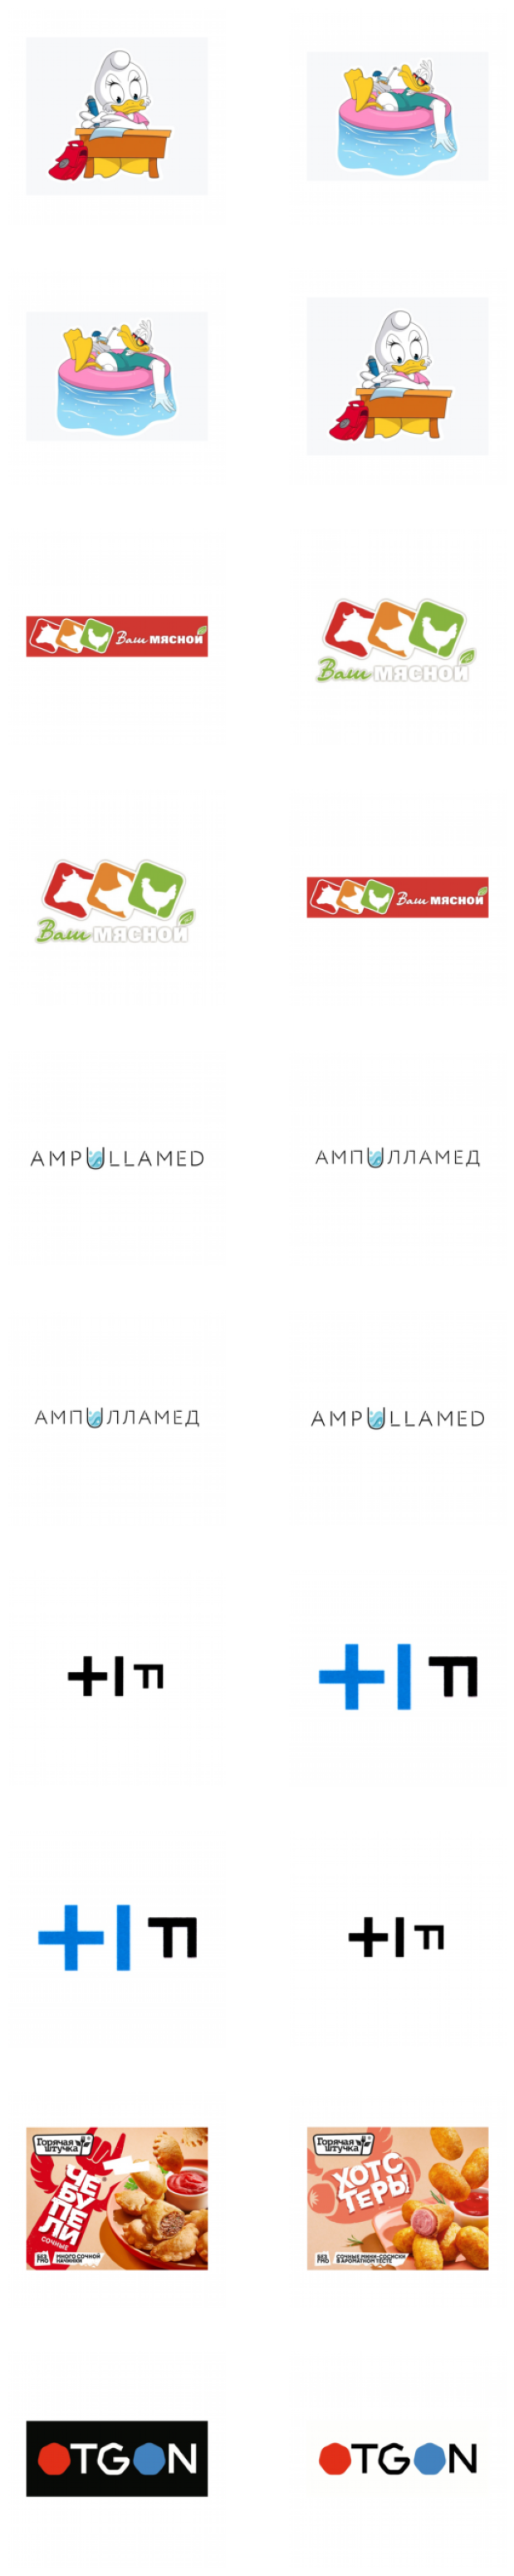

In [32]:
# Show the examples that missed
w, h = 2, 10
_, axs = plt.subplots(h, w, figsize=(w * 4, h * 4))

similarity_fn = nn.CosineSimilarity()
for ax_row, paths in tqdm(zip(axs, misses)):
    for i_col, ax in enumerate(ax_row):
        img_path = paths[i_col % 2]
        img = load_image(img_path)
        ax.set_axis_off()
        ax.imshow(img.transpose(0,1).transpose(1,2))

plt.show()